No local CSV with pit-stop target column found. Attempting Kaggle download...
Path to dataset files: /kaggle/input/datasets/aadigupta1601/f1-strategy-dataset-pit-stop-prediction
Loaded dataset from: /kaggle/input/datasets/aadigupta1601/f1-strategy-dataset-pit-stop-prediction/f1_strategy_dataset_v4.csv
Dataset name: f1_strategy_dataset_v4
Raw dataset shape: (101371, 16)
Columns: ['Driver', 'LapNumber', 'Compound', 'Stint', 'TyreLife', 'Position', 'LapTime (s)', 'Race', 'Year', 'LapTime_Delta', 'Cumulative_Degradation', 'PitStop', 'PitNextLap', 'RaceProgress', 'Normalized_TyreLife', 'Position_Change']
Features after encoding: 73
Final dataset shape: (101371, 74)
Pit-stop rate  : 0.252

Train samples  : 81,096
Test  samples  : 20,275

=== Baseline Model Evaluation ===
  Logistic Regression     Acc=0.8255  Prec=0.7124  Rec=0.5138  F1=0.5970  AUC=0.8640
  Decision Tree           Acc=0.8431  Prec=0.6872  Rec=0.6905  F1=0.6888  AUC=0.8914
  k-NN                    Acc=0.9338  Prec=0.9037  Rec

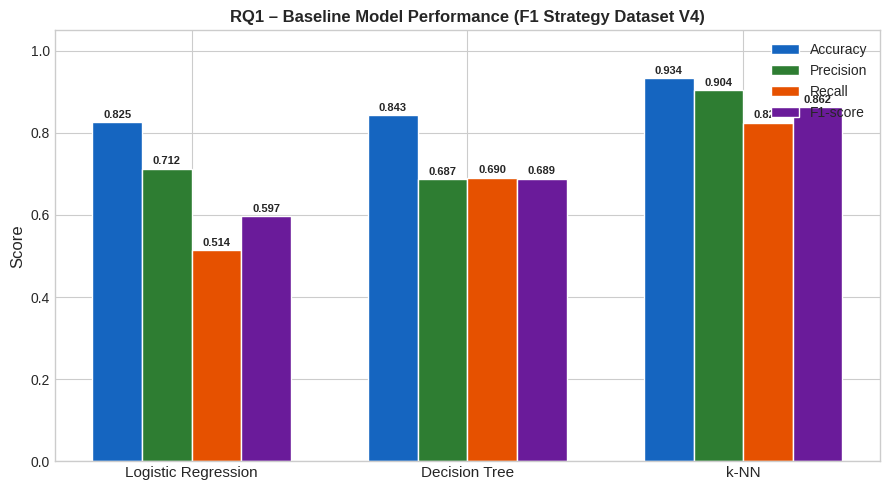

Figure saved → figures/RQ1_baseline_comparison.png


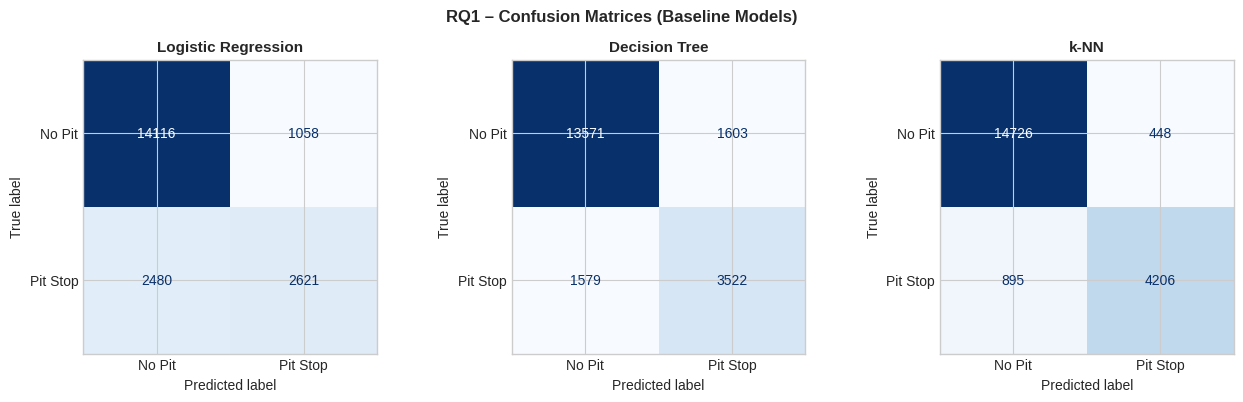

Figure saved → figures/RQ1_confusion_matrices.png

Classification Report – Logistic Regression
              precision    recall  f1-score   support

 No Pit Stop       0.85      0.93      0.89     15174
    Pit Stop       0.71      0.51      0.60      5101

    accuracy                           0.83     20275
   macro avg       0.78      0.72      0.74     20275
weighted avg       0.82      0.83      0.82     20275


Classification Report – Decision Tree
              precision    recall  f1-score   support

 No Pit Stop       0.90      0.89      0.90     15174
    Pit Stop       0.69      0.69      0.69      5101

    accuracy                           0.84     20275
   macro avg       0.79      0.79      0.79     20275
weighted avg       0.84      0.84      0.84     20275


Classification Report – k-NN
              precision    recall  f1-score   support

 No Pit Stop       0.94      0.97      0.96     15174
    Pit Stop       0.90      0.82      0.86      5101

    accuracy      

In [1]:
try:
    import kagglehub
except ImportError:
    kagglehub = None
import os
import glob
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report, ConfusionMatrixDisplay, confusion_matrix
)
import warnings
warnings.filterwarnings("ignore")

os.makedirs("figures", exist_ok=True)
np.random.seed(42)
plt.style.use("seaborn-v0_8-whitegrid")
COLORS = ["#1565C0", "#2E7D32", "#E65100", "#6A1B9A", "#B71C1C", "#006064"]

# ── 1. LOAD DATASET ──────────────────────────────────────────────────────────
# Prefer a local CSV file; fall back to Kaggle download only when needed.
local_csvs = sorted(glob.glob("*.csv"))
raw_path = None

csv_file = None
valid_targets = {"pit_stop", "PitStop", "pitstop", "pit stop"}
for candidate in local_csvs:
    try:
        sample = pd.read_csv(candidate, nrows=5)
    except Exception:
        continue
    if valid_targets.intersection(set(sample.columns.str.replace(" ", "").str.lower())):
        csv_file = candidate
        break

if csv_file is not None:
    print(f"Using local dataset file: {csv_file}")
else:
    if kagglehub is None:
        raise RuntimeError(
            "No local dataset CSV found and kagglehub is not installed. "
            "Please place the dataset CSV in this folder or install kagglehub to enable fallback download."
        )
    print("No local CSV with pit-stop target column found. Attempting Kaggle download...")
    try:
        raw_path = kagglehub.dataset_download("aadigupta1601/f1-strategy-dataset-pit-stop-prediction")
        print("Path to dataset files:", raw_path)
    except Exception as exc:
        raise RuntimeError(
            "Dataset download failed. Please place the dataset CSV in this folder or fix Kaggle SSL/authentication. "
            "If you have the CSV locally, name it something like 'f1_strategy.csv' and rerun."
        ) from exc

    if os.path.isfile(raw_path) and raw_path.lower().endswith(".zip"):
        extract_dir = os.path.splitext(raw_path)[0]
        if not os.path.exists(extract_dir):
            with zipfile.ZipFile(raw_path, "r") as archive:
                archive.extractall(extract_dir)
        data_dir = extract_dir
    else:
        data_dir = raw_path

    csv_files = glob.glob(os.path.join(data_dir, "*.csv"))
    if not csv_files:
        raise FileNotFoundError(f"No CSV files found in dataset path: {data_dir}")

    csv_file = sorted(csv_files)[0]

if csv_file is None:
    raise FileNotFoundError("No dataset CSV file could be loaded.")

df = pd.read_csv(csv_file)
dataset_name = os.path.splitext(os.path.basename(csv_file))[0]
print(f"Loaded dataset from: {csv_file}")
print(f"Dataset name: {dataset_name}")
print(f"Raw dataset shape: {df.shape}")
print("Columns:", df.columns.tolist())

# Standardize target column for pit-stop prediction.
found_target = None
for name in df.columns:
    nkey = name.replace(" ", "").replace("_", "").lower()
    if nkey == "pitstop":
        found_target = name
        break

if found_target is None:
    raise ValueError("Target column for pit-stop prediction not found in dataset")

if found_target != "pit_stop":
    df = df.rename(columns={found_target: "pit_stop"})
    found_target = "pit_stop"

# Encode non-numeric target if needed
if df[found_target].dtype == object:
    df[found_target], labels = pd.factorize(df[found_target])
    print("Target encoding:", dict(enumerate(labels)))

# Drop rows with missing labels and keep only useful features
features = [c for c in df.columns if c != found_target]
X_df = df[features].copy()
X_df = pd.get_dummies(X_df, drop_first=True)

print(f"Features after encoding: {X_df.shape[1]}")

df = pd.concat([X_df, df[[found_target]]], axis=1)
print(f"Final dataset shape: {df.shape}")
print(f"Pit-stop rate  : {df[found_target].mean():.3f}")

# ── 2. PREPROCESSING ─────────────────────────────────────────────────────────
FEATURES = [c for c in df.columns if c != found_target]
X = df[FEATURES].values
y = df[found_target].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"\nTrain samples  : {X_train.shape[0]:,}")
print(f"Test  samples  : {X_test.shape[0]:,}")

# ── 3. BASELINE MODELS ───────────────────────────────────────────────────────
baseline_models = {
    "Logistic Regression": LogisticRegression(max_iter=300, random_state=42),
    "Decision Tree":       DecisionTreeClassifier(max_depth=8, random_state=42),
    "k-NN":                KNeighborsClassifier(n_neighbors=11),
}
# LR and k-NN use scaled features; Decision Tree does not
use_scale = {"Logistic Regression": True, "Decision Tree": False, "k-NN": True}

results = {}
print("\n=== Baseline Model Evaluation ===")
for name, mdl in baseline_models.items():
    Xtr = X_train_sc if use_scale[name] else X_train
    Xte = X_test_sc  if use_scale[name] else X_test
    mdl.fit(Xtr, y_train)
    yp    = mdl.predict(Xte)
    yprob = mdl.predict_proba(Xte)[:, 1]
    results[name] = {
        "Accuracy":  accuracy_score(y_test, yp),
        "Precision": precision_score(y_test, yp, zero_division=0),
        "Recall":    recall_score(y_test, yp),
        "F1-score":  f1_score(y_test, yp),
        "AUC":       roc_auc_score(y_test, yprob),
        "y_pred": yp,
    }
    print(f"  {name:22s}  "
          f"Acc={results[name]['Accuracy']:.4f}  "
          f"Prec={results[name]['Precision']:.4f}  "
          f"Rec={results[name]['Recall']:.4f}  "
          f"F1={results[name]['F1-score']:.4f}  "
          f"AUC={results[name]['AUC']:.4f}")

# ── 4. SUMMARY TABLE ─────────────────────────────────────────────────────────
metrics = ["Accuracy", "Precision", "Recall", "F1-score", "AUC"]
res_df = pd.DataFrame(
    {name: {m: round(v, 4) for m, v in r.items() if m in metrics}
     for name, r in results.items()}
).T
print("\n--- Baseline Results Summary ---")
print(res_df.to_string())

# ── 5. FIGURE: grouped bar chart ─────────────────────────────────────────────
models_list = list(results.keys())
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(models_list))
w = 0.18
for i, m in enumerate(metrics[:4]):          # Acc / Prec / Rec / F1
    vals = [results[mdl][m] for mdl in models_list]
    bars = ax.bar(x + i * w, vals, w, label=m, color=COLORS[i], edgecolor="white")
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, v + 0.006,
                f"{v:.3f}", ha="center", va="bottom", fontsize=8, fontweight="bold")

ax.set_xticks(x + w * 1.5)
ax.set_xticklabels(models_list, fontsize=11)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Score", fontsize=12)
dataset_label = dataset_name.replace("_", " ").title()
ax.set_title(f"RQ1 – Baseline Model Performance ({dataset_label})",
             fontsize=12, fontweight="bold")
ax.legend(loc="upper right", fontsize=10)
plt.tight_layout()
plt.savefig("figures/RQ1_baseline_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved → figures/RQ1_baseline_comparison.png")

# ── 6. INDIVIDUAL CONFUSION MATRICES ─────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, (name, r) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, r["y_pred"])
    disp = ConfusionMatrixDisplay(cm, display_labels=["No Pit", "Pit Stop"])
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(name, fontsize=11, fontweight="bold")
fig.suptitle("RQ1 – Confusion Matrices (Baseline Models)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("figures/RQ1_confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved → figures/RQ1_confusion_matrices.png")

# ── 7. CLASSIFICATION REPORTS ────────────────────────────────────────────────
for name, r in results.items():
    print(f"\n{'='*50}")
    print(f"Classification Report – {name}")
    print(classification_report(y_test, r["y_pred"],
                                target_names=["No Pit Stop", "Pit Stop"]))